<a href="https://colab.research.google.com/github/farrelrassya/IntroductionMachineLearningwithpython/blob/main/10.10_Clustering_Techniques.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bab 10 - Teknik Pengelompokan (Clustering Techniques)

Notebook ini berisi hasil replikasi kode, latihan, dan penjelasan detail dari **Chapter 10 Clustering Techniques** pada buku *scikit-learn Cookbook, Third Edition*. Seluruh materi penjelasan teoretis telah diterjemahkan dan diperluas dalam **Bahasa Indonesia** secara mendalam.

In [1]:
# Muat perpustakaan
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler

# Buat kumpulan data
X, _ = make_blobs(n_samples=300, centers=4, cluster_std=0.60, random_state=2024)
X = StandardScaler().fit_transform(X)

#Bagaimana cara melakukannya...
Mari kita lihat kapan kita membuatnya. Anda juga akan melihat bahwa kami menerapkan StandardScaler() untuk mengubah nilai kami menggunakan skor-z. Ini akan membuat cluster kita lebih mudah divisualisasikan.

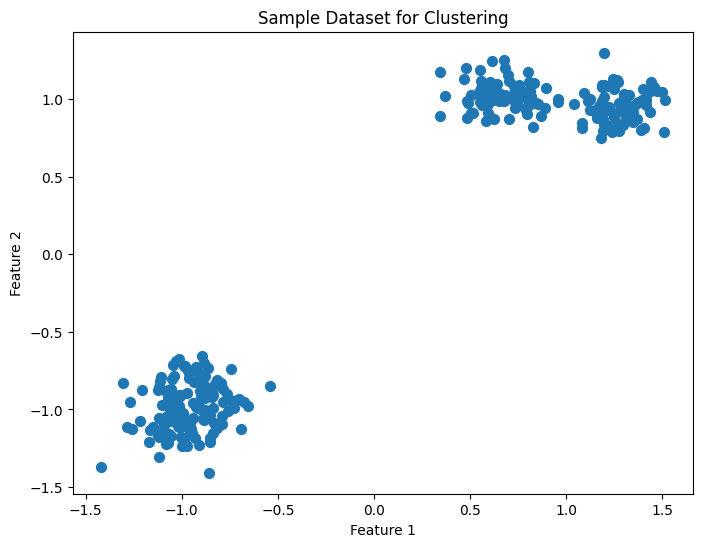

In [2]:
# Visualisasikan data mentah
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], s=50)
plt.title("Sample Dataset for Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

## Cara kerjanya...
Clustering bekerja dengan menghitung kesamaan antar titik data berdasarkan metrik jarak atau ukuran kepadatan. Tergantung pada algoritmanya, pendekatan untuk menentukan cluster dapat sangat bervariasi.

Clustering K-means
K-means adalah algoritma Clustering berbasis centroid yang mempartisi data menjadi sejumlah cluster yang telah ditentukan (yang sempurna mengingat data kita cukup “blobby” dari bagian sebelumnya). Pertama, k-means secara acak membuat centroid di ruang fitur kita. Selanjutnya, ia secara iteratif menugaskan setiap titik data ke pusat massa klaster terdekat dan kemudian menghitung ulang pusat-pusat cluster tersebut dan memindahkannya dalam ruang fitur sehingga posisinya kira-kira dalam jarak rata-rata di antara titik-titik data yang saat ini ditugaskan kepada titik-titik tersebut dalam iterasi saat ini. Proses ini berlanjut hingga “konvergensi” di mana sentroid tidak banyak berpindah dan titik data tidak dipindahkan ke pusat cluster lainnya. K-means efisien dan bekerja paling baik ketika cluster berbentuk cembung, isotropik, dan ukurannya kira-kira sama…yang juga bisa menjadi kelemahan terbesarnya.
Bersiap-siap
Di sini, kita akan menggunakan data dummy sebelumnya dan hanya memuat fungsi KMeans() dari scikit-learn.

In [3]:
# Muat perpustakaan
from sklearn.cluster import KMeans
# Gunakan kembali kumpulan data dari bagian sebelumnya
# Set data sudah dimuat dan diskalakan sebagai X


## Bagaimana cara melakukannya...
Untuk menerapkan k-means, kita cukup menyediakan n_clusters sebagai satu-satunya argumen yang diperlukan (“k” dalam “k-means” adalah referensi ke nomor cluster ini). Ini menginisialisasi jumlah centroid yang sama ketika kita memulai proses iteratif yang dijelaskan sebelumnya. Hal ini juga menyiratkan bahwa kita mengetahui atau setidaknya dapat memperkirakan jumlah cluster sebelumnya. Hal ini juga bisa menjadi potensi keterbatasan k-means jika kita tidak memiliki perkiraan untuk memulainya. Namun, biasanya kami mengambil langkah untuk menyempurnakan nilai ini seperti yang akan kita lihat di bawah.

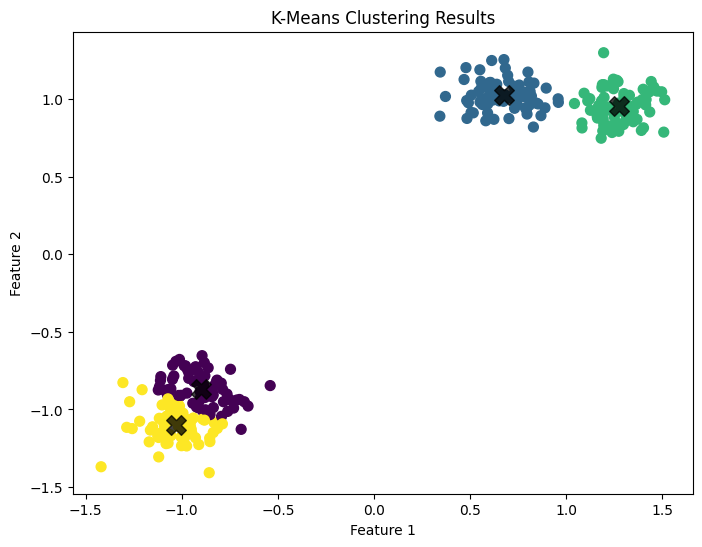

In [4]:
# Terapkan Clustering K-Means
kmeans = KMeans(n_clusters=4, random_state=2024)
y_kmeans = kmeans.fit_predict(X)

# Plot data yang dikelompokkan
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y_kmeans, s=50, cmap='viridis')
centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='black', s=200, alpha=0.75, marker='X')
plt.title("K-Means Clustering Results")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

## Cara kerjanya...
K-Means mengikuti pendekatan penyempurnaan berulang:
- Inisialisasi: Centroid cluster “k” diinisialisasi secara acak atau menggunakan metode seperti 'k-means++'.
- Langkah Penugasan: Setiap titik data ditetapkan ke pusat massa terdekat berdasarkan metrik jarak (biasanya jarak Euclidean yang menggunakan jarak garis lurus umum yang dijelaskan menggunakan koordinat x/y).
- Langkah Pembaruan: Pusat massa setiap cluster dihitung ulang sebagai rata-rata semua poin yang ditetapkan.
Proses ini berlanjut hingga penugasan tidak lagi berubah (konvergensi) atau jumlah iterasi maksimum tercapai. K-means meminimalkan varians dalam cluster (inersia).
Plot ini menampilkan empat cluster yang ditemukan oleh K-Means, beserta sentroidnya masing-masing yang ditandai dengan X hitam.

Masih ada lagi...
Bagaimana cara memilih jumlah cluster yang optimal? Salah satu metode populer untuk menentukan nilai “k” terbaik adalah metode siku. Ini melibatkan pembuatan plot jumlah jarak kuadrat (inersia) untuk rentang nilai “k” dan mencari titik di mana menambahkan lebih banyak cluster akan menghasilkan keuntungan yang semakin berkurang.

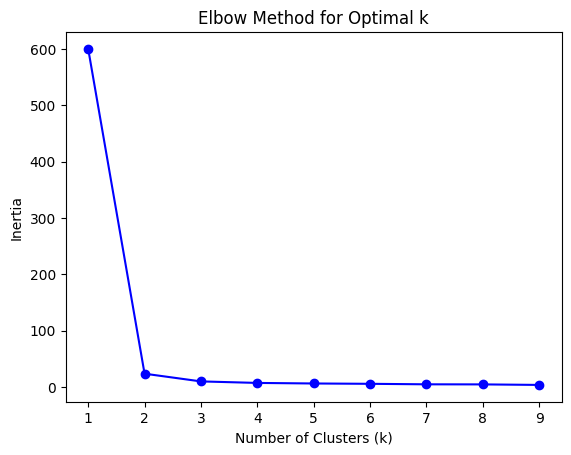

In [5]:
# Hitung dan plot inersia Clustering
inertia = []
k_values = range(1, 10)
for k in k_values:
    km = KMeans(n_clusters=k, random_state=2024)
    km.fit(X)
    inertia.append(km.inertia_)

plt.plot(k_values, inertia, 'bo-')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal k")
plt.show()

# Clustering Hierarki
Clustering hierarki membangun cluster bersarang dengan menggabungkan atau memisahkannya secara berurutan. Hal ini sangat berguna ketika jumlah cluster tidak diketahui sebelumnya, dan menyediakan struktur seperti pohon (dendogram) yang secara visual menyampaikan hubungan antar data. Ini merupakan perbaikan pada k-means yang membutuhkan nilai “k” sebelum dieksekusi. Ada dua pendekatan utama: aglomeratif (bottom-up) dan memecah-belah (top-down). Dalam praktiknya, Clustering aglomeratif lebih umum digunakan dan didukung secara langsung di scikit-learn.

## Bersiap
Seperti sebelumnya, kita dapat menggunakan kumpulan data yang sama yang kita buat sebelumnya dan cukup menerapkan teknik baru ke dalamnya dengan mengimpor kelas scikit-learn dan fungsi pembantu.

In [6]:
# Muat perpustakaan
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

# Gunakan kembali kumpulan data dari bagian sebelumnya
# Set data sudah dimuat dan diskalakan sebagai X


## Bagaimana cara melakukannya...
Di sini, kami menerapkan Clustering aglomeratif. Kita dapat menentukan sejumlah klaster, atau kita dapat menentukan ambang batas metrik jarak untuk membuat titik potong untuk jumlah klaster yang dikembalikan – salah satunya, namun dalam bentuknya yang paling murni, tidak diperlukan jumlah klaster tertentu.

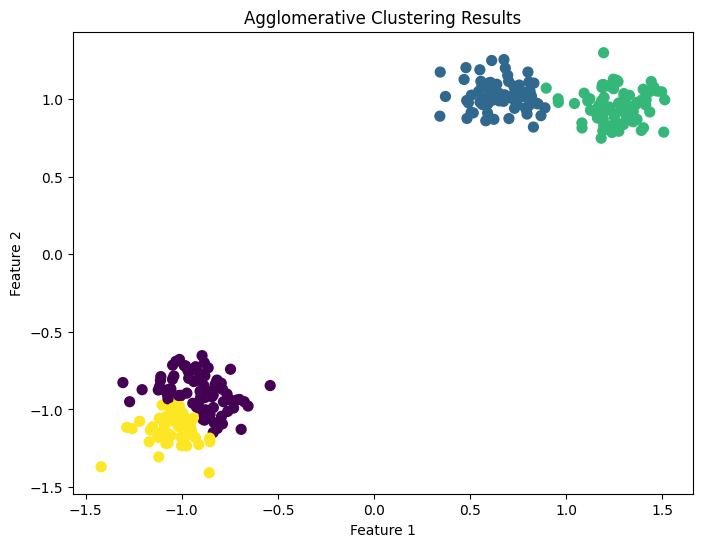

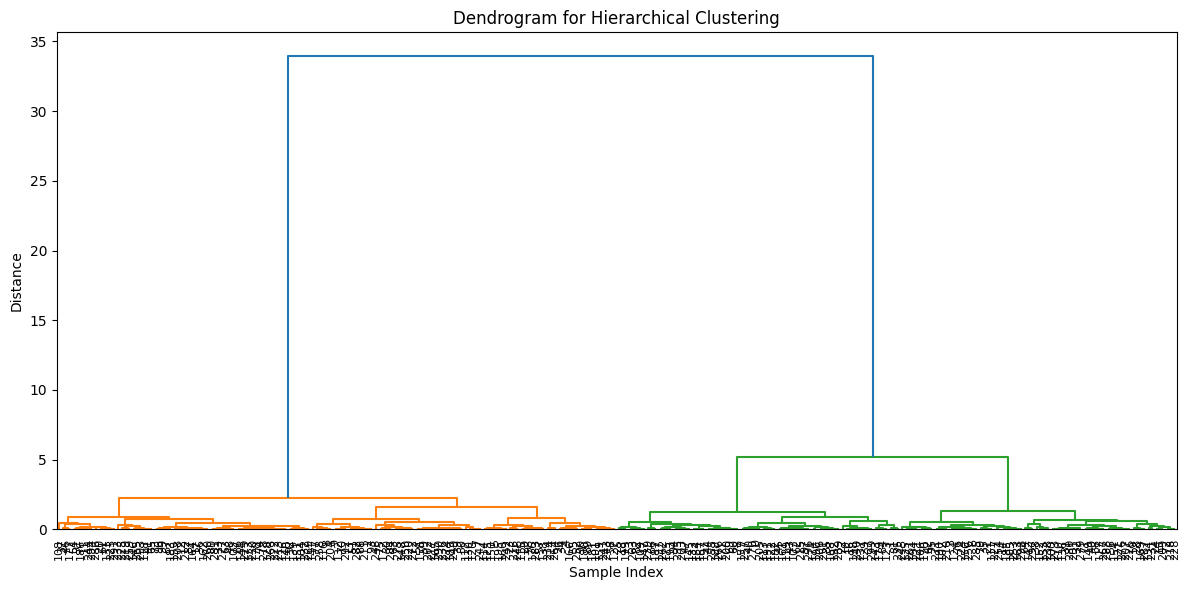

In [7]:
# Terapkan Clustering aglomeratif
agg = AgglomerativeClustering(n_clusters=4)
y_agg = agg.fit_predict(X)

# Plot data yang dikelompokkan
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y_agg, cmap='viridis', s=50)
plt.title("Agglomerative Clustering Results")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

# Hasilkan dendrogram menggunakan SciPy
linked = linkage(X, method='ward')
plt.figure(figsize=(12, 6))
dendrogram(linked, leaf_rotation=90, leaf_font_size=8)
plt.title("Dendrogram for Hierarchical Clustering")
plt.xlabel("Sample Index")
plt.ylabel("Distance")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

## Cara kerjanya...
Clustering aglomeratif mengikuti pendekatan bottom-up:
- Setiap titik data dimulai sebagai clusternya sendiri.
- Pada setiap langkah, dua cluster terdekat digabungkan berdasarkan kriteria keterkaitan.
- Ini berlanjut hingga semua titik digabungkan menjadi satu cluster atau hingga kondisi penghentian (seperti jumlah cluster yang telah ditentukan sebelumnya) terpenuhi.
Metode linkage menentukan cara menghitung jarak antar cluster:
- Ward: Meminimalkan varian cluster yang digabungkan (default dan paling umum digunakan)
- Lengkap : Jarak maksimum antar titik dalam dua cluster
- Rata-rata: Jarak rata-rata antara semua pasangan titik
- Tunggal : Jarak minimum antar titik
Dendrogram memvisualisasikan proses Clustering dan dapat memandu pemilihan jumlah cluster dengan memilih ketinggian untuk "memotong" pohon.

## Masih ada lagi...
Dendrogram sangat berguna untuk memahami struktur data. Jika cluster-clusternya terpisah dengan baik, ketinggian jarak keterkaitan akan menunjukkan kesenjangan yang jelas. Hal ini dapat membantu dalam menentukan apakah ada Clustering alami dalam data.
Meskipun scikit-learn tidak memberikan dukungan asli untuk Clustering yang memecah-belah (top-down), pendekatan serupa dapat diterapkan menggunakan alat lain atau algoritme khusus. Clustering yang memecah belah dimulai dengan semua titik dalam satu cluster dan secara rekursif membaginya.

# Clustering Berbasis Kepadatan dengan DBSCAN
DBSCAN (Clustering Spasial Berbasis Kepadatan Aplikasi dengan Kebisingan) adalah algoritma Clustering unik yang mampu mengidentifikasi kelompok dengan berbagai bentuk dan ukuran. Ini berbeda dari K-means dan Clustering hierarki karena tidak memerlukan jumlah cluster yang ditentukan terlebih dahulu dan dengan menangani outlier (noise) secara efektif. Artinya, tidak seperti k-means, k-means tidak menghasilkan centroid secara apriori.

## Bersiap
Di sini, kita akan menggunakan fungsi penghasil data lain di scikit-learn yang disebut make_moons(), yang, sekali lagi, seperti make_blobs() diberi nama yang tepat!

In [8]:
# Muat perpustakaan
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_moons

# Buat yang baru dengan noise
X, _ = make_moons(n_samples=300, noise=0.1, random_state=2024)

## Bagaimana cara melakukannya...
Mari kita jalankan DBSCAN. Dalam contoh ini kita menetapkan dua argumen terpenting, eps dan min_samples, masing-masing menjadi 0,2 dan 5. Lebih lanjut tentang ini di bawah.

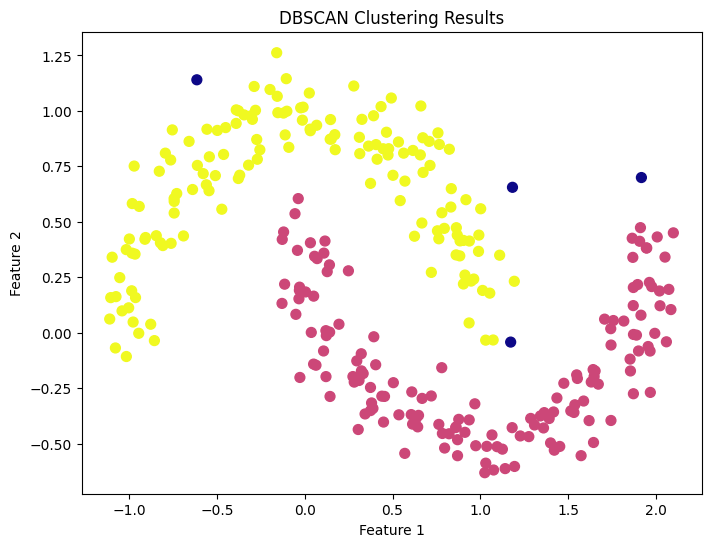

In [9]:
# Terapkan DBSCAN
dbscan = DBSCAN(eps=0.2, min_samples=5)
y_db = dbscan.fit_predict(X)

# Plot hasil DBSCAN
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y_db, cmap='plasma', s=50)
plt.title("DBSCAN Clustering Results")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

## Cara kerjanya...
DBSCAN mengelompokkan titik data berdasarkan dua parameter utama:
- eps : Jari-jari lingkungan sekitar suatu titik.
- min_samples: Jumlah minimum titik yang diperlukan untuk membentuk wilayah padat.
Poin diklasifikasikan menjadi tiga kategori:
- Poin inti: Memiliki setidaknya min_samples dalam jarak eps.
- Titik batas: Berada dalam lingkungan eps titik inti tetapi memiliki tetangga yang lebih sedikit dari min_samples itu sendiri.
- Titik kebisingan: Bukan titik inti maupun titik batas.
DBSCAN memulai dari titik yang belum dikunjungi, memeriksa “lingkungan”-nya, dan membentuk cluster dengan secara rekursif memasukkan tetangga yang terhubung dengan kepadatan. Ini sangat baik dalam mengidentifikasi kelompok non-bola dan memisahkan kebisingan yang sangat berharga dalam aplikasi dunia nyata di mana data sering kali “kotor.”

## Masih ada lagi...
Bagaimana Anda memilih eps dan min_samples? Kinerja DBSCAN sensitif terhadap pilihan eps dan min_samples. Plot k-distance dapat membantu menentukan nilai yang baik untuk eps. Plot jarak ke k-Nearest Neighbors (k-NN)e-k (di mana k = min_samples) untuk semua titik dan cari tikungan tajam (siku).

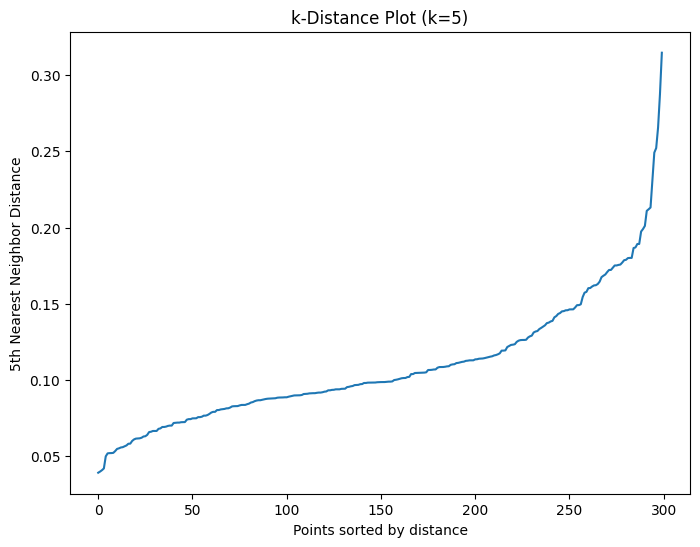

In [10]:
# Memuat perpustakaan
from sklearn.neighbors import NearestNeighbors

# Hasilkan k-Nearest Neighbors (k-NN)
neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X)
distances, indices = neighbors_fit.kneighbors(X)
distances = np.sort(distances[:, 4])

# Plot jarak-k
plt.figure(figsize=(8, 6))
plt.plot(distances)
plt.title("k-Distance Plot (k=5)")
plt.xlabel("Points sorted by distance")
plt.ylabel("5th Nearest Neighbor Distance")
plt.show()

# Metrik Evaluasi Klaster
Mengevaluasi hasil Clustering sangat penting untuk menilai kualitas dan relevansi Clustering yang ditemukan oleh algoritma tanpa pengawasan. Namun, tidak seperti pembelajaran yang diawasi, Clustering tidak memiliki label atau nilai target sebenarnya yang ingin kami prediksi, jadi kami mengandalkan metrik evaluasi internal dan eksternal seperti skor siluet, indeks Davies-Bouldin, dan indeks Rand yang disesuaikan untuk menentukan seberapa baik kinerja model. Sekali lagi, dengan teknik pembelajaran tanpa pengawasan, evaluasi dapat dilihat lebih sebagai suatu seni daripada sains, namun kita masih dapat membuat keputusan yang tepat dengan alat yang tepat.

## Bersiap
Untuk memulai, kita akan memuat metrik evaluasi, membuat kumpulan data dummy, dan menyesuaikan model Clustering k-means.

In [11]:
# Muat perpustakaan
from sklearn.metrics import silhouette_score, davies_bouldin_score, adjusted_rand_score
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans

# Hasilkan kumpulan data berlabel untuk evaluasi
X, y_true = make_blobs(n_samples=300, centers=4, cluster_std=0.60, random_state=2024)

# Cocokkan KMeans untuk digunakan dengan metrik evaluasi
kmeans = KMeans(n_clusters=4, random_state=2024)
y_kmeans = kmeans.fit_predict(X)

## Bagaimana cara melakukannya...
Penerapan teknik evaluasi sangatlah mudah dan hanya membutuhkan data masukan dan model yang dilatih.

In [12]:
# Hitung skor siluet
sil_score = silhouette_score(X, y_kmeans)
print(f"Silhouette Score: {sil_score:.3f}")

# Hitung indeks Davies-Bouldin
db_index = davies_bouldin_score(X, y_kmeans)
print(f"Davies-Bouldin Index: {db_index:.3f}")

# (Opsional) Hitung indeks Rand yang disesuaikan jika kebenaran dasar diketahui
ari = adjusted_rand_score(y_true, y_kmeans)
print(f"Adjusted Rand Index: {ari:.3f}")

Silhouette Score: 0.534
Davies-Bouldin Index: 0.702
Adjusted Rand Index: 0.814


## Cara kerjanya...
- **Skor Siluet**: mengukur seberapa mirip suatu titik dengan klasternya sendiri dibandingkan dengan klaster lain. Nilainya berkisar antara -1 (Clustering buruk) hingga 1 (kelompok padat dan terpisah dengan baik). Nilai yang lebih tinggi menunjukkan klaster yang terdefinisi lebih baik.
- **Indeks Davies-Bouldin**: mengevaluasi rasio kesamaan rata-rata setiap cluster dengan cluster yang paling mirip. Nilai yang lebih rendah menunjukkan Clustering yang lebih baik. Berbeda dengan skor siluet, metrik ini menghukum kelompok yang tumpang tindih.
- **Indeks Rand yang Disesuaikan (ARI)**: membandingkan hasil Clustering dengan kebenaran dasar yang diketahui dengan memeriksa semua pasangan sampel dan menghitung pasangan yang ditugaskan ke kluster yang sama atau berbeda. Ini mengoreksi peluang dan berkisar dari -1 hingga 1, di mana 1 menunjukkan kesesuaian sempurna.

## Masih ada lagi...
Metrik tambahan yang perlu dipertimbangkan mencakup Indeks Calinski-Harabasz.  Hal ini juga disebut kriteria rasio varians dan mendukung cluster yang terpisah dengan baik dan padat. Seperti indeks Davies-Bouldin, indeks ini dihitung menggunakan dispersi intra-cluster dan antar-cluster.

# Memilih Algoritma Clustering yang Tepat
Pemilihan algoritma Clustering yang paling sesuai sangat bergantung pada struktur dan properti kumpulan data. Tidak ada solusi yang universal—algoritme yang berbeda akan disesuaikan dengan jenis distribusi data, tingkat kebisingan, dan dimensi yang berbeda! Bagian ini membandingkan karakteristik utama dari algoritma Clustering dan memberikan panduan untuk memilih di antara mereka.

## Bersiap
Mari kita mulai dengan membuat berbagai kumpulan data dummy menggunakan fungsi scikit-learn yang telah kita gunakan sebelumnya.

In [13]:
# Muat perpustakaan
from sklearn.datasets import make_moons, make_blobs, make_circles
from sklearn.preprocessing import StandardScaler

# Buat dan skalakan kumpulan data yang berbeda
X_blobs, _ = make_blobs(n_samples=300, centers=3, cluster_std=0.6, random_state=2024)
X_moons, _ = make_moons(n_samples=300, noise=0.1, random_state=2024)
X_circles, _ = make_circles(n_samples=300, noise=0.05, factor=0.5, random_state=2024)

X_blobs = StandardScaler().fit_transform(X_blobs)
X_moons = StandardScaler().fit_transform(X_moons)
X_circles = StandardScaler().fit_transform(X_circles)

#Bagaimana cara melakukannya...
Setiap struktur data cocok untuk algoritma Clustering tertentu.

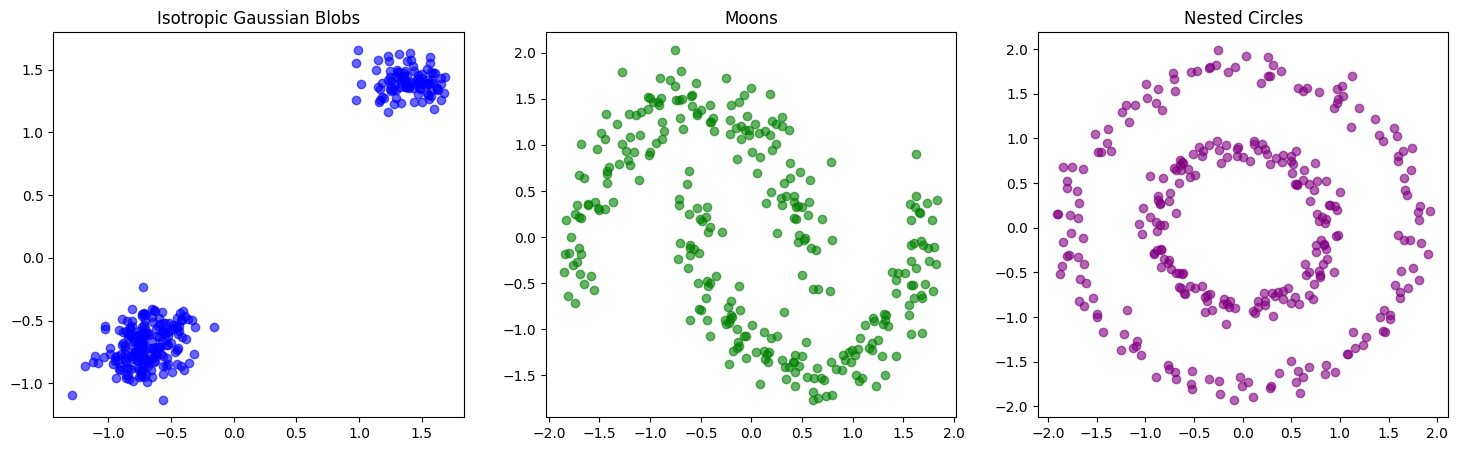

In [14]:
# Visualisasikan kumpulan data
fig, axs = plt.subplots(1, 3, figsize=(18, 5))
axs[0].scatter(X_blobs[:, 0], X_blobs[:, 1], c='blue', alpha=0.6)
axs[0].set_title("Isotropic Gaussian Blobs")
axs[1].scatter(X_moons[:, 0], X_moons[:, 1], c='green', alpha=0.6)
axs[1].set_title("Moons")
axs[2].scatter(X_circles[:, 0], X_circles[:, 1], c='purple', alpha=0.6)
axs[2].set_title("Nested Circles")
plt.show()

## Cara kerjanya...
Saat memilih algoritma Clustering, pertimbangkan faktor-faktor berikut:
- Bentuk Cluster: K-Means bekerja dengan baik dengan cluster cembung. DBSCAN atau Clustering spektral lebih cocok untuk bentuk non-cembung.
- Penanganan Kebisingan: DBSCAN secara eksplisit menangani kebisingan dengan mengidentifikasi outlier sebagai sesuatu yang terpisah dari cluster. K-Means dan Clustering hierarki menetapkan semua titik ke sebuah cluster.
- Skalabilitas: K-Means dapat diskalakan dengan baik pada kumpulan data besar. Clustering hierarki kurang dapat diskalakan karena kompleksitas waktunya.
- Sensitivitas Parameter:
  - K-Means: sensitif terhadap k dan inisialisasi.
  - DBSCAN: sensitif terhadap eps dan min_samples.
  - Clustering aglomeratif: dipengaruhi oleh metode keterkaitan dan kriteria penghentian.
- Dimensi: Clustering dalam dimensi tinggi sering kali memerlukan pengurangan dimensi (misalnya PCA) terlebih dahulu karena kutukan dimensi.

## Masih ada lagi...
Memilih teknik Clustering Anda harus didasarkan pada karakteristik data Anda. Ada baiknya untuk merencanakan kumpulan data mentah Anda terlebih dahulu untuk mencoba mengidentifikasi struktur mendasar yang dapat memandu pendekatan Anda.

# Teknik Clustering Tingkat Lanjut
Di luar algoritme Clustering “klasik”, scikit-learn menawarkan beberapa teknik lanjutan seperti Spectral Clustering dan Gaussian Mixture Models (GMMs). Metode ini memberikan lebih banyak fleksibilitas dalam memodelkan bentuk klaster yang kompleks dan penetapan klaster probabilistik, menjadikannya berguna untuk tugas yang lebih bernuansa.

## Bersiap
Mari kita mulai dengan memuat dua model Clustering baru dan membuat beberapa data dummy untuk mengujinya.

In [15]:
# Muat perpustakaan
from sklearn.cluster import SpectralClustering
from sklearn.mixture import GaussianMixture
# Buat kumpulan data dengan struktur kompleks
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler

X, _ = make_moons(n_samples=300, noise=0.05, random_state=2024)
X = StandardScaler().fit_transform(X)

## Bagaimana cara melakukannya...
Setiap model dipasang dengan cara yang sama seperti model sebelumnya.

C:\Users\62812\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:328: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


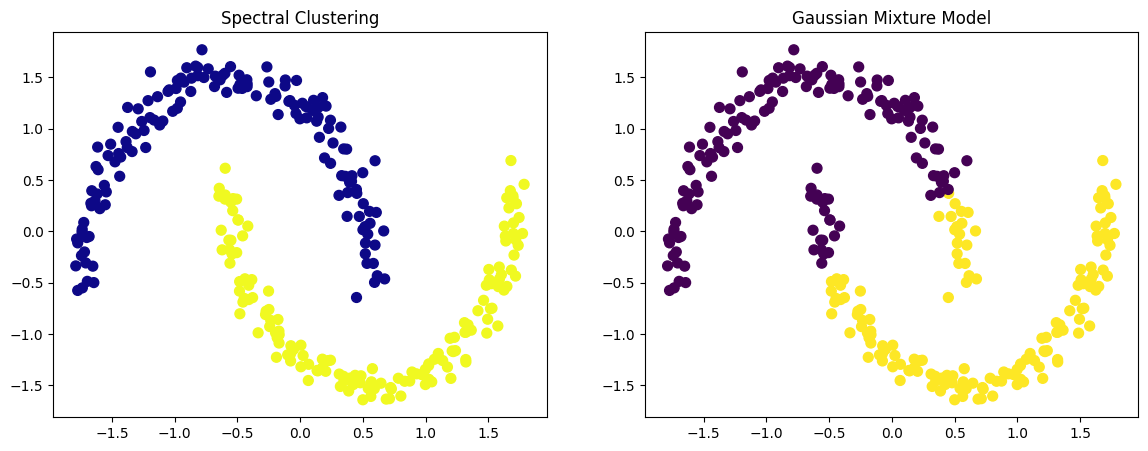

In [16]:
# Terapkan Clustering Spektral
spectral = SpectralClustering(n_clusters=2, affinity='nearest_neighbors', random_state=2024)
y_spectral = spectral.fit_predict(X)

# Terapkan Model Campuran Gaussian
gmm = GaussianMixture(n_components=2, random_state=2024)
y_gmm = gmm.fit_predict(X)

# Visualisasikan kedua hasil Clustering
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.scatter(X[:, 0], X[:, 1], c=y_spectral, cmap='plasma', s=50)
ax1.set_title("Spectral Clustering")

ax2.scatter(X[:, 0], X[:, 1], c=y_gmm, cmap='viridis', s=50)
ax2.set_title("Gaussian Mixture Model")

plt.show()

## Cara kerjanya...
Mari kita lihat lebih dekat masing-masing teknik ini untuk memahami cara kerjanya.

### Clustering Spektral
- Membuat grafik kesamaan dari data.
- Membangun matriks yang mewakili hubungan antara titik data.
- Memetakan grafik berdimensi tinggi ini ke ruang fitur berdimensi lebih rendah.
- Menerapkan K-means pada representasi yang dikurangi.
Metode ini efektif untuk cluster non-cembung dan dipengaruhi oleh ukuran kesamaan (misalnya basis radial, k-Nearest Neighbors (k-NN)). Ini juga berfungsi dengan baik pada kumpulan data besar dengan banyak fitur.

### Model Campuran Gaussian (GMM)
- GMM adalah metode “Clustering lunak” yang didasarkan pada asumsi bahwa data dihasilkan dari campuran beberapa distribusi Gaussian (atau normal).
- Setiap titik diberi probabilitas untuk menjadi bagian dari setiap cluster.
- Algoritma Expectation-Maximization (EM) digunakan untuk mencari parameter yang memaksimalkan kemungkinan data.
- GMM menawarkan fleksibilitas dalam menangkap bentuk elips dan cluster yang tumpang tindih dan dapat digunakan untuk deteksi anomali atau klasifikasi probabilistik. Karena ketergantungannya pada estimasi probabilitas, GMM dapat dengan lancar menetapkan data ke cluster bergantung pada ambang batas, jika diperlukan.

## Masih ada lagi...
- Memvisualisasikan probabilitas cluster dengan GMM menyediakan metode prediksi_proba untuk menunjukkan kemungkinan setiap titik milik setiap cluster. Hal ini dapat berguna ketika ketidakpastian mengenai penetapan cluster titik data mulai terjadi.
- Selain itu, seseorang dapat menerapkan pengurangan Dimensi dengan Clustering tingkat lanjut. Metode Clustering tingkat lanjut seperti Clustering Spektral dapat memperoleh manfaat dari pengurangan dimensi sebelumnya (misalnya PCA atau t-SNE), terutama dengan data berdimensi tinggi. Langkah ini meningkatkan kinerja dan interpretabilitas.

# Latihan Praktek dengan Model Clustering
Di bagian akhir ini, pembaca akan terlibat dalam latihan praktis yang melibatkan pembuatan, penyesuaian, dan evaluasi model Clustering pada kumpulan data dunia nyata. Latihan-latihan ini dirancang untuk memperkuat konsep-konsep yang dipelajari sepanjang bab ini dan menunjukkan bagaimana menerapkan teknik Clustering secara efektif dalam berbagai skenario. Di akhir bagian ini, pembaca akan mendapatkan pengalaman langsung yang dapat mereka manfaatkan dalam proyek ML mereka sendiri.

## Latihan 1: Clustering dengan K-Means pada Dataset Iris
Dalam contoh ini, kami akan menerapkan Clustering K-Means ke kumpulan data Iris yang terkenal dan mengevaluasi hasilnya menggunakan beberapa metrik.

### Langkah Penerapan:

Silhouette Score: 0.553
Adjusted Rand Index: 0.730


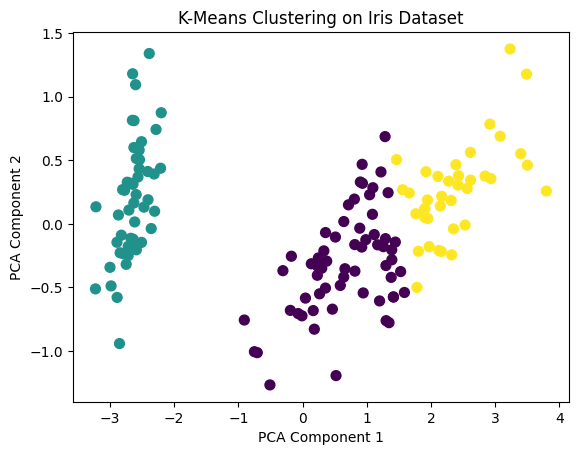

In [17]:
# Memuat perpustakaan
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score
import matplotlib.pyplot as plt

# Muat Set Data
iris = load_iris()
X = iris.data
y_true = iris.target

# Buat dan Latih Model KMeans
kmeans = KMeans(n_clusters=3, random_state=2024)
y_kmeans = kmeans.fit_predict(X)

# Evaluasi Clustering
sil_score = silhouette_score(X, y_kmeans)
ari = adjusted_rand_score(y_true, y_kmeans)

print(f"Silhouette Score: {sil_score:.3f}")
print(f"Adjusted Rand Index: {ari:.3f}")

# Visualisasikan Penugasan Cluster (Proyeksi PCA)
from sklearn.decomposition import PCA

X_pca = PCA(n_components=2).fit_transform(X)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_kmeans, cmap='viridis', s=50)
plt.title("K-Means Clustering on Iris Dataset")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()

## Latihan 2: Membandingkan DBSCAN dan K-Means pada Data Bulan
Latihan ini menunjukkan bagaimana DBSCAN dapat mengungguli K-Means pada data dengan bentuk non-cembung.

### Langkah Penerapan:

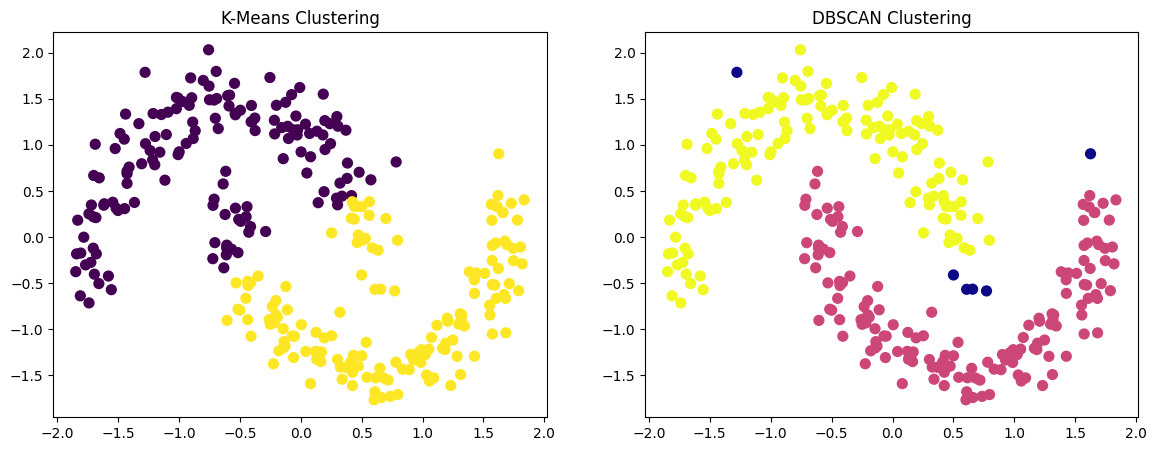

In [18]:
# Memuat perpustakaan
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN, KMeans
import matplotlib.pyplot as plt

# Buat dan Skalakan Kumpulan Data
X, _ = make_moons(n_samples=300, noise=0.1, random_state=2024)
X = StandardScaler().fit_transform(X)

# Terapkan KMeans dan DBSCAN
kmeans = KMeans(n_clusters=2, random_state=2024)
y_kmeans = kmeans.fit_predict(X)

dbscan = DBSCAN(eps=0.3, min_samples=5)
y_dbscan = dbscan.fit_predict(X)

# Visualisasikan Hasil Clustering
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.scatter(X[:, 0], X[:, 1], c=y_kmeans, cmap='viridis', s=50)
ax1.set_title("K-Means Clustering")

ax2.scatter(X[:, 0], X[:, 1], c=y_dbscan, cmap='plasma', s=50)
ax2.set_title("DBSCAN Clustering")

plt.show()

## Latihan 3: Mengelompokkan Data Dimensi Tinggi dengan PCA + GMM
Latihan ini menggabungkan Dimensionality Reduction dengan pendekatan Clustering probabilistik menggunakan Model Campuran Gaussian.

### Langkah Penerapan:

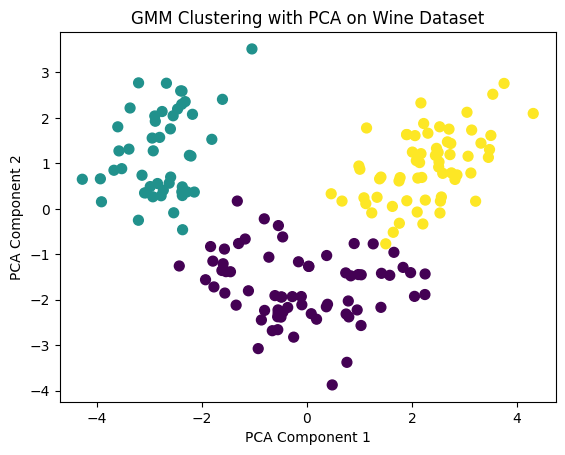

In [19]:
# Memuat perpustakaan
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt

# Muat dan Praproses Kumpulan Data
data = load_wine()
X = StandardScaler().fit_transform(data.data)

# Terapkan PCA untuk Pengurangan Dimensi
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Model Campuran Gaussian yang Cocok
gmm = GaussianMixture(n_components=3, random_state=2024)
y_gmm = gmm.fit_predict(X_pca)

# Visualisasikan Output Berkelompok
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_gmm, cmap='viridis', s=50)
plt.title("GMM Clustering with PCA on Wine Dataset")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()

### Ringkasan dan Pandangan (Summary and Outlook)

#### 1. Ringkasan Bab
Dalam bab ini, kita mempelajari berbagai metode pengelompokan (*Clustering*) tanpa pengawasan:
* **K-Means Clustering:** Mengelompokkan data berdasarkan jarak ke pusat kluster (centroids) secara iteratif.
* **Hierarchical Clustering (Agglomerative):** Membangun kluster secara bertahap seperti pohon hierarki (dendrogram).
* **DBSCAN:** Pengelompokan berbasis kepadatan, sangat efektif untuk kluster dengan bentuk tidak beraturan dan otomatis mendeteksi kebisingan (noise).
* **Gaussian Mixture Models (GMM):** Pengelompokan probabilistik yang mengasumsikan data berasal dari kombinasi beberapa distribusi Gaussian.
* **Metrik Evaluasi:** Menggunakan Silhouette Score, Davies-Bouldin Index, dan Calinski-Harabasz Score untuk menilai kualitas kluster.

#### 2. Pandangan ke Depan
Clustering membantu kita menemukan pola tersembunyi dan mengelompokkan data secara alami. Metode unsupervised lainnya yang sangat berguna di industri adalah deteksi anomali. Pada **Bab 11**, kita akan mempelajari teknik deteksi pencilan (*Outlier Detection*) untuk menyaring data mencurigakan atau tidak biasa.